In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
import matplotlib.pyplot as plt
import tqdm

from transformers import AutoTokenizer

In [19]:
metrics = pd.read_csv("training_metrics_3016.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'training_metrics_3016.csv'

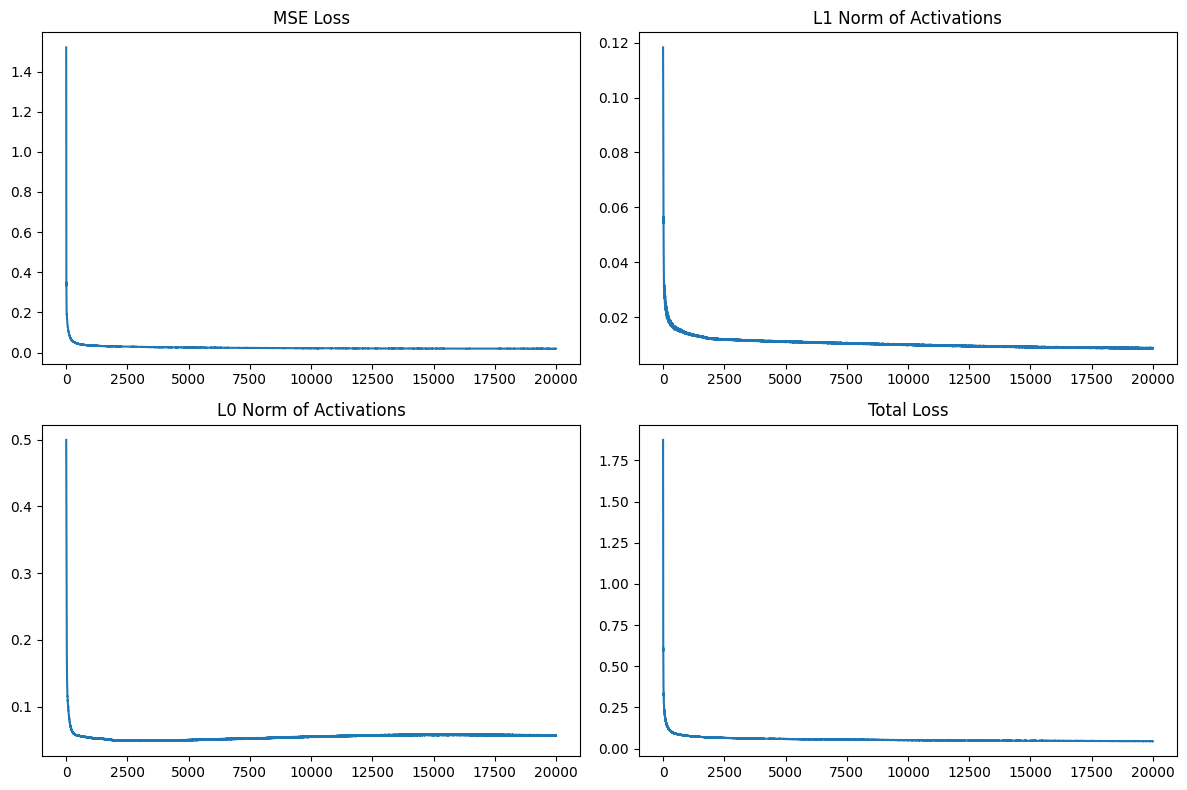

In [20]:
# plot the metrics
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(metrics['mse'])
plt.title('MSE Loss')
plt.subplot(2, 2, 2)
plt.plot(metrics['l1'])
plt.title('L1 Norm of Activations')
plt.subplot(2, 2, 3)
plt.plot(metrics['l0'])
plt.title('L0 Norm of Activations')
plt.subplot(2, 2, 4)
plt.plot(metrics['loss'])
plt.title('Total Loss')
plt.tight_layout()
plt.show()

In [ ]:
from sae import SparseAutoEncoder
from datasets import load_dataset

# Load tokenizer only (no need for the full model)
tokenizer = AutoTokenizer.from_pretrained("EleutherAI/pythia-70m")

EXPANSION = 8  # change this to inspect different expansion factors
MODEL_PATH = f"saved_models/sae_model_{EXPANSION}x.pt"

# Load saved SAE
d = 512
m = d * EXPANSION
sae = SparseAutoEncoder(d=d, m=m)
sae.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
sae.eval()

# Load activations and process through SAE encoder in batches
# Full encoder output would be ~88GB, so we process in chunks
NUM_TEXTS = 50000
ACTIVATIONS_PATH = f"activations/activations_{NUM_TEXTS}.pt"

activations = torch.load(ACTIVATIONS_PATH, map_location="cpu")
n_tokens = activations.shape[0]
BATCH_SIZE = 4096

# We only need top-k per feature, so we track running top-k instead of storing everything
K = 20  # track top-K activating tokens per feature
top_vals = torch.zeros(m, K)
top_idxs = torch.full((m, K), -1, dtype=torch.long)

with torch.no_grad():
    for start in tqdm.trange(0, n_tokens, BATCH_SIZE):
        batch = activations[start:start + BATCH_SIZE]
        feat_acts = sae.encoder(batch)  # (batch, m)

        for j in range(feat_acts.shape[1]):
            combined_vals = torch.cat([top_vals[j], feat_acts[:, j]])
            combined_idxs = torch.cat([top_idxs[j], torch.arange(start, start + feat_acts.shape[0])])
            best = combined_vals.topk(K)
            top_vals[j] = best.values
            top_idxs[j] = combined_idxs[best.indices]

del activations

# Re-tokenize the same texts to get token strings
# TransformerLens prepends a BOS token per text, so we must do the same
dataset = load_dataset("openwebtext", split="train", streaming=True)
BOS = tokenizer.bos_token_id

all_tokens = []
all_contexts = []
for i, example in enumerate(tqdm.tqdm(dataset, total=NUM_TEXTS)):
    if i >= NUM_TEXTS:
        break
    text = example["text"][:512]
    token_ids = [BOS] + tokenizer.encode(text, add_special_tokens=False)
    tokens = [tokenizer.decode(tid) for tid in token_ids]
    for t in tokens:
        all_tokens.append(t)
        all_contexts.append(text)

print(f"Total tokens: {len(all_tokens)}, activations: {n_tokens}")
assert len(all_tokens) == n_tokens, f"Mismatch! tokens={len(all_tokens)} vs activations={n_tokens}"
print(f"Tracked top-{K} activations for {m} features")

In [52]:
df_row = next(iter(dataset))

print(df_row['text'])

Port-au-Prince, Haiti (CNN) -- Earthquake victims, writhing in pain and grasping at life, watched doctors and nurses walk away from a field hospital Friday night after a Belgian medical team evacuated the area, saying it was concerned about security.

The decision left CNN Chief Medical Correspondent Sanjay Gupta as the only doctor at the hospital to get the patients through the night.

CNN initially reported, based on conversations with some of the doctors, that the United Nations ordered the Belgian First Aid and Support Team to evacuate. However, Belgian Chief Coordinator Geert Gijs, a doctor who was at the hospital with 60 Belgian medical personnel, said it was his decision to pull the team out for the night. Gijs said he requested U.N. security personnel to staff the hospital overnight, but was told that peacekeepers would only be able to evacuate the team.

He said it was a "tough decision" but that he accepted the U.N. offer to evacuate after a Canadian medical team, also at the

In [23]:
def inspect_feature(feature_idx, k=10):
    k = min(k, K)
    vals = top_vals[feature_idx, :k]
    idxs = top_idxs[feature_idx, :k]

    print(f"Feature {feature_idx} — top {k} activating tokens:\n")
    for val, idx in zip(vals, idxs):
        idx = idx.item()
        if idx < 0:
            break
        token = all_tokens[idx]
        context = all_contexts[idx]
        print(f"  {val:.3f}  token={repr(token):>15s}   context: {context[:80]}")

# try a few features
inspect_feature(2)
print()
inspect_feature(100)

Feature 2 — top 10 activating tokens:

  2.194  token=         ' Feb'   context: Peter G. Aiken/Getty Images

The Cleveland Browns have endured another regime ch
  2.157  token=         ' Feb'   context: SEX, LOVE & HEALTH A-FAIRE

Monday, Feb. 10, 2014

Sac City Student Center

12 n
  2.148  token=         ' Feb'   context: Frank Victores/Associated Press

Cincinnati Bengals tight end Tyler Eifert suffe
  2.129  token=         ' Feb'   context: LGBT ATL turns on its heart lights. Whether you’re courting a sweetie, consideri
  2.129  token=         ' Feb'   context: Deanna Durante was in court during the "Black Madam" trial. Find out who the she
  2.091  token=         ' Feb'   context: NYPD auxiliary officers James Kiernan (left) and Jordan Martinez are accused of 
  2.056  token=         ' Feb'   context: Buy Photo Thomas Earl Crossley holds his sons old ASU baseball jersey as his wif
  2.055  token=         ' Feb'   context: The Winter Olympics is coming! In an inspired move, NBC ha

In [24]:
# Features where the best activation is 0 are dead
alive_mask = top_vals[:, 0] > 0
dead_count = (~alive_mask).sum().item()

# Sort alive features by their top activation (lowest = sparsest)
alive_idxs = torch.where(alive_mask)[0]
sorted_order = top_vals[alive_idxs, 0].argsort()
sparsest_idxs = alive_idxs[sorted_order]

print(f"Dead features: {dead_count} / {m}")
print()
for idx in sparsest_idxs[:10]:
    idx = idx.item()
    # Count non-zero entries in top-K as a proxy
    n_active = (top_vals[idx] > 0).sum().item()
    print(f"Feature {idx}: top activation = {top_vals[idx, 0]:.4f} ({n_active}/{K} top slots active)")
    inspect_feature(idx, k=5)
    print()

Dead features: 4 / 4096

Feature 1846: top activation = 0.0017 (1/20 top slots active)
Feature 1846 — top 5 activating tokens:

  0.002  token=          ' 10'   context: At 10 o’clock in the evening we arrived. The train stopped. We went onto the pla

Feature 3638: top activation = 0.0057 (1/20 top slots active)
Feature 3638 — top 5 activating tokens:

  0.006  token=        ' held'   context: BAGHDAD — As Iraq emerges from three years of war with the Islamic State group, 

Feature 691: top activation = 0.0068 (1/20 top slots active)
Feature 691 — top 5 activating tokens:

  0.007  token=        ' like'   context: Formula 1's omnipresent pursuit of safety usually remains under the radar and it

Feature 1233: top activation = 0.0082 (4/20 top slots active)
Feature 1233 — top 5 activating tokens:

  0.008  token=      ' series'   context: While popular documentary films like Fahrenheit 9/11 and No End In Sight explore
  0.005  token=            '0'   context: Cornucopia 0.3.3 - Legendari

In [25]:
# Rank features by strongest top activation
best_per_feature = top_vals[:, 0]
ranked = best_per_feature.argsort(descending=True)

for rank, idx in enumerate(ranked[:20]):
    idx = idx.item()
    print(f"=== Rank {rank+1}: Feature {idx} (top activation: {best_per_feature[idx]:.3f}) ===")
    inspect_feature(idx, k=5)
    print()

=== Rank 1: Feature 3289 (top activation: 168.386) ===
Feature 3289 — top 5 activating tokens:

  168.386  token=            '.'   context: Δραματικά είναι τα στοιχεία για την κατάσταση στην αγορά εργασίας στην χώρας μας
  162.418  token=            '.'   context: Self-driving electric cars? Rad!! A Hyperloop train that can get you from New Yo
  162.109  token=            '.'   context: Fox News Channel pundits Greta Van Susteren and Erick Erickson have gone to war 
  161.757  token=            '.'   context: According to court documents, 29-year-old Markus Kaarma of Missoula, Mont. was i
  161.663  token=            '.'   context: Poison Ivy is a 1985 American made-for-television romantic comedy film starring 

=== Rank 2: Feature 3348 (top activation: 28.609) ===
Feature 3348 — top 5 activating tokens:

  28.609  token=            '.'   context: At MWC 2016, OPPO released its new SmartSensor image stabilization technology. A
  28.554  token=            '.'   context: A local police o

In [26]:
# Find the most "interpretable" features: ones where top-K tokens are consistent
# Score = fraction of top-K tokens that match the most common token
# Filter out single-char punctuation which dominates the max-activation ranking
from collections import Counter

BORING = {'.', "'", '-', '"', ',', '!', '?', ':', ';', '\n', ' ', ''}

scores = []
for feat_idx in range(m):
    idxs = top_idxs[feat_idx]
    valid = idxs[idxs >= 0]
    if len(valid) < 5:
        scores.append((feat_idx, 0.0, ""))
        continue
    tokens = [all_tokens[i.item()] for i in valid]
    counts = Counter(tokens)
    most_common_token, most_common_count = counts.most_common(1)[0]
    consistency = most_common_count / len(tokens)
    scores.append((feat_idx, consistency, most_common_token))

# Sort by consistency, filter out punctuation-only features
scores_filtered = [(idx, score, tok) for idx, score, tok in scores
                   if tok.strip() not in BORING and len(tok.strip()) > 0]
scores_filtered.sort(key=lambda x: -x[1])

print("Most consistent (interpretable) features:\n")
for feat_idx, consistency, top_token in scores_filtered[:30]:
    # if len(top_token) == 2:
    #     continue
    print(f"Feature {feat_idx}: {consistency:.0%} consistent, top token = {repr(top_token)}, max act = {top_vals[feat_idx, 0]:.3f}")
    inspect_feature(feat_idx, k=5)
    print()

Most consistent (interpretable) features:

Feature 1: 100% consistent, top token = ' ca', max act = 1.808
Feature 1 — top 5 activating tokens:

  1.808  token=          ' ca'   context: Star forward Eddie Betts will be entertaining Crows fans for years to come after
  1.757  token=          ' ca'   context: The family of Michael Brown appeared on NBC’s “Today” show, during which they we
  1.752  token=          ' ca'   context: Credit: Marvel Comics

Horror fiction icon R.L. Stine makes his comic book writi
  1.740  token=          ' ca'   context: Twenty years after helping his injured son across the finish line in Barcelona, 
  1.722  token=          ' ca'   context: TO HEAR Gov. Larry Hogan (R) tell it, Maryland is sinking fast, its people fleei

Feature 2: 100% consistent, top token = ' Feb', max act = 2.194
Feature 2 — top 5 activating tokens:

  2.194  token=         ' Feb'   context: Peter G. Aiken/Getty Images

The Cleveland Browns have endured another regime ch
  2.157  token=

In [27]:
inspect_feature(3440, k=5)
print()

Feature 3440 — top 5 activating tokens:

  7.957  token=      'Reuters'   context: March 13 (Reuters) - U.S. investigators suspect that Malaysia Airlines Flight 37
  7.946  token=      'Reuters'   context: MANILA (Reuters) - The Philippine government derided Catholic bishops on Sunday 
  7.946  token=      'Reuters'   context: MANILA (Reuters) - Philippine Vice President Jejomar Binay on Monday vowed to am
  7.924  token=      'Reuters'   context: DUBAI, April 4 (Reuters) - Iran has partially lifted a ban on women attending me
  7.902  token=      'Reuters'   context: NEW YORK, July 6 (Reuters) - A former Goldman Sachs (GS.N) computer programmer a



# W_dec Cosine Similarity Analysis

In [29]:
!pip install scipy

  Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_arm64.whl.metadata (61 kB)
Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_arm64.whl (22.4 MB)


In [30]:
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# Normalize decoder weights and compute pairwise cosine similarity
W_dec = sae.W_dec.data.clone()  # (m, d)
W_dec_normed = W_dec / W_dec.norm(dim=1, keepdim=True)
cos_sim = W_dec_normed @ W_dec_normed.T  # (m, m)

# Zero out the diagonal for analysis (self-similarity = 1 is uninteresting)
cos_sim_no_diag = cos_sim.clone()
cos_sim_no_diag.fill_diagonal_(0)

print(f"Decoder weight matrix: {W_dec.shape}")
print(f"Cosine similarity matrix: {cos_sim.shape}")
print(f"Max off-diagonal similarity: {cos_sim_no_diag.max():.4f}")
print(f"Mean off-diagonal similarity: {cos_sim_no_diag.sum() / (m * (m - 1)):.4f}")

Decoder weight matrix: torch.Size([4096, 512])
Cosine similarity matrix: torch.Size([4096, 4096])
Max off-diagonal similarity: 0.8024
Mean off-diagonal similarity: 0.0015


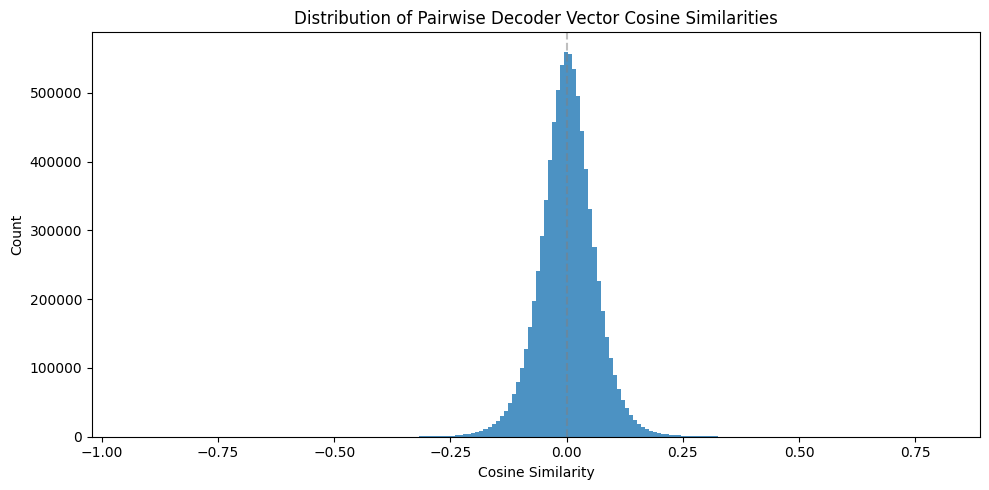

Pairs with |cos_sim| > 0.5: 472
Pairs with |cos_sim| > 0.7: 80
Pairs with |cos_sim| > 0.9: 11


In [31]:
# Histogram of pairwise cosine similarities (upper triangle only to avoid double-counting)
upper_tri = cos_sim[torch.triu(torch.ones(m, m, dtype=torch.bool), diagonal=1)].numpy()

plt.figure(figsize=(10, 5))
plt.hist(upper_tri, bins=200, edgecolor='none', alpha=0.8)
plt.xlabel("Cosine Similarity")
plt.ylabel("Count")
plt.title("Distribution of Pairwise Decoder Vector Cosine Similarities")
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Pairs with |cos_sim| > 0.5: {(np.abs(upper_tri) > 0.5).sum()}")
print(f"Pairs with |cos_sim| > 0.7: {(np.abs(upper_tri) > 0.7).sum()}")
print(f"Pairs with |cos_sim| > 0.9: {(np.abs(upper_tri) > 0.9).sum()}")

In [34]:
# Inspect the most similar feature pairs, skipping features whose top token is a single char
N_PAIRS = 20
sim_flat = cos_sim_no_diag.flatten()
top_pair_indices = sim_flat.argsort(descending=True)

def top_token(feat_idx):
    idx = top_idxs[feat_idx, 0].item()
    return all_tokens[idx].strip() if idx >= 0 else ""

print(f"Top {N_PAIRS} most similar feature pairs (filtered to meaningful tokens):\n")
seen = set()
count = 0
for flat_idx in top_pair_indices:
    if count >= N_PAIRS:
        break
    i = flat_idx.item() // m
    j = flat_idx.item() % m
    pair = (min(i, j), max(i, j))
    if pair in seen:
        continue
    seen.add(pair)
    # Skip pairs where either feature's top token is a single character or empty
    tok_i, tok_j = top_token(i), top_token(j)
    if len(tok_i) <= 1 or len(tok_j) <= 1:
        continue
    sim_val = cos_sim[i, j].item()
    print(f"Features {i} & {j}: cosine sim = {sim_val:.4f}")
    inspect_feature(i, k=3)
    inspect_feature(j, k=3)
    print("-" * 80)
    count += 1

Top 20 most similar feature pairs (filtered to meaningful tokens):

Features 3041 & 3961: cosine sim = 0.7074
Feature 3041 — top 3 activating tokens:

  6.853  token=         ' may'   context: Dragon's Dogma

Capcom

Rated By Our Customers Compatible with PlayStation 3™ (P
  6.819  token=        ' will'   context: About

So please, support us TODAY and be part of the Holiplay experience where 
  6.657  token=        ' will'   context: This is a design for a hotel room with a king-size bed at the Old Post Office bu
Feature 3961 — top 3 activating tokens:

  5.334  token=           '10'   context: Blog Archive Mar 2018 (2) Feb 2018 (5) Jan 2018 (9) Dec 2017 (1) Apr 2017 (4) Ma
  5.117  token=         'uchi'   context: Jones

vs.

Cormier Cerrone

vs.

Jury Tavares

vs.

Marquardt Horiguchi

vs.

G
  4.915  token=            '3'   context: July (1) January (1) November (1) September (2) June (1) March (1) January (1) N
----------------------------------------------------------------------

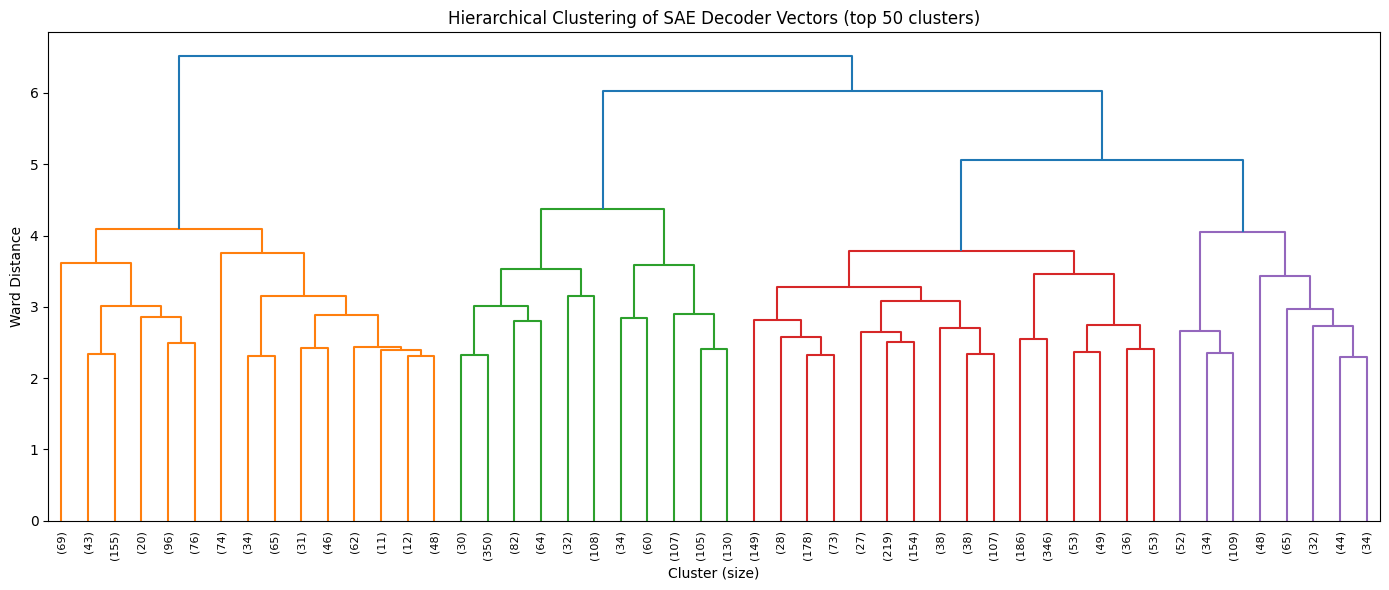

In [33]:
# Hierarchical clustering of decoder vectors + dendrogram
# Use cosine distance = 1 - cosine_similarity
cos_dist = 1 - cos_sim.numpy()
np.fill_diagonal(cos_dist, 0)
cos_dist = np.clip(cos_dist, 0, 2)  # ensure no negative distances from floating point

condensed_dist = squareform(cos_dist)
Z = linkage(condensed_dist, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=50, leaf_rotation=90, leaf_font_size=8,
           show_leaf_counts=True)
plt.title("Hierarchical Clustering of SAE Decoder Vectors (top 50 clusters)")
plt.xlabel("Cluster (size)")
plt.ylabel("Ward Distance")
plt.tight_layout()
plt.show()

In [46]:
def search_token(query, k=5):
    """Find features whose top-K activating tokens match the query.
    
    Matches any token containing the query string (case-insensitive).
    """
    results = []
    for feat_idx in range(m):
        idxs = top_idxs[feat_idx]
        valid = idxs[idxs >= 0]
        for rank, tok_idx in enumerate(valid[:K]):
            tok = all_tokens[tok_idx.item()]
            if query.lower() in tok.lower():
                results.append((feat_idx, rank, top_vals[feat_idx, rank].item(), tok))
                break  # only count best rank per feature

    results.sort(key=lambda x: x[1])  # sort by rank (0 = top token)
    print(f"Features with '{query}' in top-{K} tokens: {len(results)}\n")
    for feat_idx, rank, val, tok in results[:20]:
        print(f"  Feature {feat_idx}: rank={rank}, activation={val:.3f}, token={repr(tok)}")
    return results

# Example usage:
search_token("bridge")
print()

Features with 'bridge' in top-20 tokens: 2

  Feature 2623: rank=8, activation=2.121, token='bridge'
  Feature 3982: rank=16, activation=0.970, token='bridge'



In [47]:
inspect_feature(2623, k=10)

Feature 2623 — top 10 activating tokens:

  2.318  token=         'idin'   context: Hesperidin (4'-methoxy-7-O-rutinosyl-3',5-dihydroxyflavanone), a naturally occur
  2.248  token=          'son'   context: Gladson Dungdung is either a security threat, or the Indian government doesn't w
  2.195  token=          'ine'   context: Slitherine (www.slitherine.com) and Games Workshop (www.games-workshop.com), two
  2.173  token=          'one'   context: Naloxone is commonly used to reverse narcotic intoxication. However, its use is 
  2.168  token=            'a'   context: Haumea: Technique and Rationale

Yesterday’s look at a fast orbiter mission to H
  2.155  token=           'on'   context: Avalon (아발론) was released in December 2014 to be introduced in the HungryApp Sta
  2.148  token=          'ane'   context: Macfarlane says it's an inevitable change — and that's why the company is now fo
  2.138  token=          'isa'   context: Marilisa Harvey (Photo: CCSO)

A Naples woman arrested 